replication of GKX paper:
https://academic.oup.com/rfs/article/33/5/2223/5758276#supplementary-data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import pyarrow

In [15]:
print("Loading data...")
chars_df = pd.read_csv("/Users/shadowform/Documents/#Unito/CodesAndProjects/EquityCharacteristics-master/datashare/datashare.csv")
wrds_df = pd.read_csv('data_csv/CRSP_returns.csv')
ff3_df = pd.read_csv('data_csv/ff3.csv') 
macro_df = pd.read_csv('data_csv/Goyal_Welch_2024.csv')

print("Data loaded successfully!")

Loading data...
Data loaded successfully!


In [16]:
# Standardize date formats to YYYYMM integer format for all datasets

# 1. chars_df: It's an integer like 19570131. 
# Floor dividing by 100 chops off the last two digits (the days), leaving 195701.
chars_df['YYYYMM'] = chars_df['DATE'] // 100

# 2. wrds_df: It's a string like '1986-01-31'. 
# Convert to datetime, extract the Year/Month, and cast to integer.
wrds_df['YYYYMM'] = pd.to_datetime(wrds_df['MthCalDt']).dt.strftime('%Y%m').astype(int)

# 3. ff3_df: It's a string like '1957-01-31'. 
# Identical logic to the WRDS dataset.
ff3_df['YYYYMM'] = pd.to_datetime(ff3_df['dateff']).dt.strftime('%Y%m').astype(int)

# 4. macro_df: It's already in the perfect YYYYMM integer format (like 194505)!
# We just duplicate it into our standardized column name for the merge.
macro_df['YYYYMM'] = macro_df['yyyymm']
# drop the original 'yyyymm' column to avoid confusion later
macro_df.drop(columns=['yyyymm'], inplace=True)

print("All dates successfully standardized to YYYYMM integer format!")

print(f"\nchars time range: {chars_df['YYYYMM'].min()} to {chars_df['YYYYMM'].max()}")
print(f"wrds time range: {wrds_df['YYYYMM'].min()} to {wrds_df['YYYYMM'].max()}")
print(f"ff3 time range: {ff3_df['YYYYMM'].min()} to {ff3_df['YYYYMM'].max()}")
print(f"macro time range: {macro_df['YYYYMM'].min()} to {macro_df['YYYYMM'].max()}")

print("\nso we need to prune the data for optimized memory usage!")

# Helper function to shift YYYYMM by a specified number of months
# This is crucial for aligning macro variables from month t to the stock returns in month t+1.
def shift_yyyymm(values, months):
    dates = pd.to_datetime(pd.Series(values).astype(str), format="%Y%m")
    shifted = dates + pd.DateOffset(months=months)
    return shifted.dt.strftime("%Y%m").astype(int)

All dates successfully standardized to YYYYMM integer format!

chars time range: 195701 to 202112
wrds time range: 195701 to 202512
ff3 time range: 195701 to 202602
macro time range: 187101 to 202312

so we need to prune the data for optimized memory usage!


In [17]:
print("--- Early Memory Optimization: Truncating to Paper Sample Window ---")
start_date = 195703
end_date = 201612
# This shifts the start date back by one month
start_minus_1 = int(shift_yyyymm([start_date], -1).iloc[0])

print("Filtering Characteristics...")
chars_df = chars_df[(chars_df['YYYYMM'] >= start_date) & (chars_df['YYYYMM'] <= end_date)].copy()

print("Filtering WRDS Returns...")
# We should keep one extra month of WRDS data (starting from 195702) to have the necessary lagged returns for the first month of our sample (195703).
wrds_df = wrds_df[(wrds_df['YYYYMM'] >= start_minus_1) & (wrds_df['YYYYMM'] <= end_date)].copy()

print("Filtering Fama-French...")
ff3_df = ff3_df[(ff3_df['YYYYMM'] >= start_date) & (ff3_df['YYYYMM'] <= end_date)].copy()

print("Filtering Macro Variables...")
# We use month t macro data for month t+1 returns, so we need to start from one month before the sample window (195702)
macro_df = macro_df[(macro_df['YYYYMM'] >= start_minus_1) & (macro_df['YYYYMM'] <= end_date)].copy()

print("Datasets successfully truncated! This will save massive amounts of RAM.")

--- Early Memory Optimization: Truncating to Paper Sample Window ---
Filtering Characteristics...
Filtering WRDS Returns...
Filtering Fama-French...
Filtering Macro Variables...
Datasets successfully truncated! This will save massive amounts of RAM.


In [18]:
print("Merging Fama-French into WRDS...")
# A tiny merge (800 rows into 5M)
wrds_df = pd.merge(wrds_df, ff3_df[['YYYYMM', 'rf']], on='YYYYMM', how='left')

print("Calculating Target Variable...")
wrds_df['excess_ret'] = wrds_df['MthRet'] - wrds_df['rf']

# Print the raw descriptive statistics to check for impossible minimums/maximums
print("\n--- Summary Statistics for Excess Return ---")
print(wrds_df['excess_ret'].describe())
ret_skewness = wrds_df['excess_ret'].skew()
ret_excess_kurtosis = wrds_df['excess_ret'].kurt() # or .ret_kurtosis()
raw_kurtosis = ret_excess_kurtosis + 3
print(f"Skewness: {ret_skewness:.2f}")
print(f"Excess Kurtosis (Fisher): {ret_excess_kurtosis:.2f}")
print(f"Raw Kurtosis (Pearson): {raw_kurtosis:.2f}")

Merging Fama-French into WRDS...
Calculating Target Variable...

--- Summary Statistics for Excess Return ---
count    3.959895e+06
mean     6.857865e-03
std      1.714018e-01
min     -1.012400e+00
25%     -6.332400e-02
50%     -2.800000e-03
75%      6.088800e-02
max      2.399660e+01
Name: excess_ret, dtype: float64
Skewness: 6.75
Excess Kurtosis (Fisher): 354.86
Raw Kurtosis (Pearson): 357.86


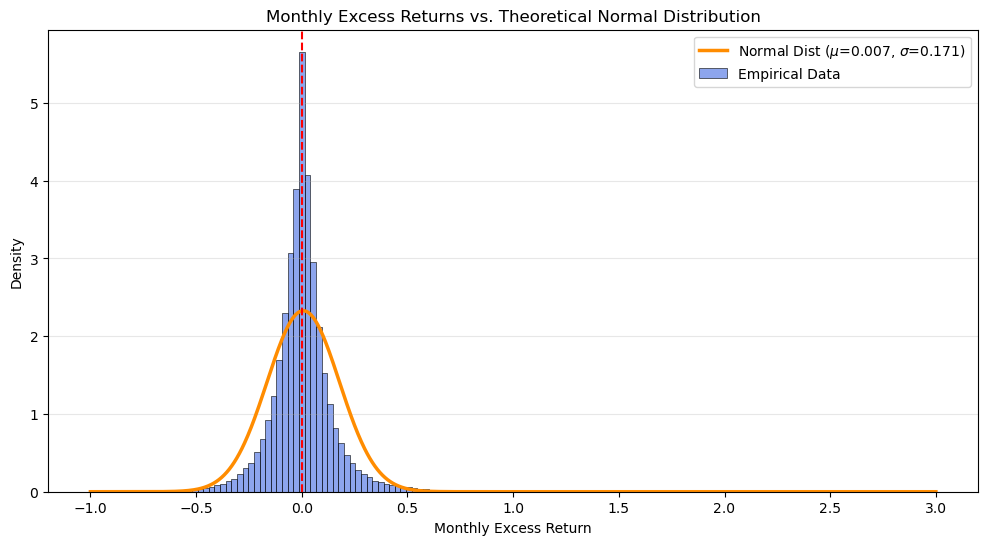

In [19]:
# Visualizing the Excess Returns vs. Normal Distribution

# Calculate the actual mean and standard deviation of your target variable
mu = wrds_df['excess_ret'].mean()
sigma = wrds_df['excess_ret'].std()

plt.figure(figsize=(12, 6))

# Plot the histogram as a DENSITY instead of raw counts
sns.histplot(
    wrds_df['excess_ret'].clip(-1, 3), 
    bins=150, 
    stat='density', # Crucial change!
    kde=False,      # Turning off seaborn's KDE so we can draw the pure normal curve
    color='royalblue', 
    alpha=0.6, 
    label='Empirical Data'
)

# Create the x-axis points for the normal curve
x = np.linspace(-1, 3, 1000)

# Calculate the normal distribution y-values using our empirical mean and std
y_normal = norm.pdf(x, mu, sigma)

# Plot the theoretical normal curve on top
plt.plot(x, y_normal, color='darkorange', linewidth=2.5, 
         label=fr'Normal Dist ($\mu$={mu:.3f}, $\sigma$={sigma:.3f})')

plt.title('Monthly Excess Returns vs. Theoretical Normal Distribution')
plt.xlabel('Monthly Excess Return')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.legend()

plt.show()

In [20]:
# Calculating lagged market cap for value-weighted portfolio construction
print("Calculating lagged market capitalization for each stock-month...")
wrds_df = wrds_df.rename(columns={'PERMNO': 'permno'})
wrds_df = wrds_df.sort_values(["permno", "YYYYMM"]).copy()

wrds_df["market_cap_eom"] = wrds_df["MthPrc"].abs() * wrds_df["ShrOut"]

lagged_market_cap = (
    wrds_df[["permno", "YYYYMM", "market_cap_eom"]]
    .dropna(subset=["market_cap_eom"])
    .drop_duplicates(["permno", "YYYYMM"], keep="last")
    .copy()
)

# Month t market cap becomes the portfolio weight for return month t+1.
lagged_market_cap["YYYYMM"] = shift_yyyymm(
    lagged_market_cap["YYYYMM"], 1
).to_numpy()

lagged_market_cap = lagged_market_cap.rename(
    columns={"market_cap_eom": "market_cap"}
)

wrds_df = wrds_df.merge(
    lagged_market_cap,
    on=["permno", "YYYYMM"],
    how="left",
    validate="many_to_one",
)

# Keep only the essential primary keys and our target variable from WRDS
wrds_clean = wrds_df.loc[
    wrds_df["YYYYMM"].between(start_date, end_date),
    ["permno", "YYYYMM", "excess_ret", "market_cap"],
].copy()


# keep only the essential primary keys and characteristics from the characteristics dataset
chars_clean = chars_df.drop(columns=['DATE']).copy()

print("Executing the Final Grand Merge...")
# The inner join perfectly aligns the 94 characteristics with our calculated target returns
final_dataset = pd.merge(
    chars_clean, 
    wrds_clean, 
    on=['permno', 'YYYYMM'], 
    how='inner'
)

final_dataset = final_dataset.sort_values(['permno', 'YYYYMM']).reset_index(drop=True)
print(f"\nGrand Merge Complete! Final dataset shape: {final_dataset.shape}")

Calculating lagged market capitalization for each stock-month...
Executing the Final Grand Merge...

Grand Merge Complete! Final dataset shape: (3801467, 99)


In [21]:
# Standardizing characteristicsto [-1, 1]

# Columns that are NOT firm characteristics
non_char_cols = ['permno', 'YYYYMM', 'sic2', 'market_cap', 'excess_ret']

# Infer the 94 characteristic columns
char_cols = [col for col in final_dataset.columns if col not in non_char_cols]

print(f"Number of characteristic columns detected: {len(char_cols)}")
assert len(char_cols) == 94, f"Expected 94 characteristics, found {len(char_cols)}"

print("Standardizing characteristics month by month to the [-1, 1] interval...")

# Cross-sectional rank transform within each month
# Missing values stay missing here and will be handled in the next step
final_dataset[char_cols] = (
    final_dataset
    .groupby('YYYYMM')[char_cols]
    .transform(lambda x: 2 * ((x.rank(method='average') - 1) / (x.count() - 1)) - 1 if x.count() > 1 else np.nan)
)

print("Standardization complete.")

# Optional diagnostic
print("\nSummary of standardized characteristics:")
print(final_dataset[char_cols].agg(['min', 'median', 'max']).T.head(5))


Number of characteristic columns detected: 94
Standardizing characteristics month by month to the [-1, 1] interval...


Standardization complete.

Summary of standardized characteristics:
             min  median       max
mvel1  -1.000000     0.0  1.000000
beta   -0.991402     0.0  0.991402
betasq -1.000000     0.0  0.991402
chmom  -0.991402     0.0  0.991402
dolvol -1.000000     0.0  0.991274


In [22]:
print("Imputing standardized characteristics with monthly cross-sectional medians...")

# Columns that are NOT firm characteristics
# non_char_cols = ['permno', 'YYYYMM', 'sic2', 'market_cap', 'excess_ret']
# Infer the 94 characteristic columns
# char_cols = [col for col in final_dataset.columns if col not in non_char_cols]
# print(f"Number of characteristic columns detected: {len(char_cols)}")
# assert len(char_cols) == 94, f"Expected 94 characteristics, found {len(char_cols)}"

# Missing values before imputation
missing_before = final_dataset[char_cols].isna().sum().sum()
print(f"Total missing characteristic values before median imputation: {missing_before:,}")

# Monthly cross-sectional median imputation on the standardized scale
monthly_char_medians = final_dataset.groupby('YYYYMM')[char_cols].transform('median')
final_dataset[char_cols] = final_dataset[char_cols].fillna(monthly_char_medians)

# Missing values after median imputation
missing_after = final_dataset[char_cols].isna().sum().sum()
print(f"Total missing characteristic values after median imputation: {missing_after:,}")

# These remaining missings come from where the characteristic is missing for all firms in that month
remaining_missing_by_char = final_dataset[char_cols].isna().sum().sort_values(ascending=False)

print("\nTop 10 characteristics by remaining missing count:")
print(remaining_missing_by_char.head(5))


Imputing standardized characteristics with monthly cross-sectional medians...
Total missing characteristic values before median imputation: 108,464,013
Total missing characteristic values after median imputation: 9,975,616

Top 10 characteristics by remaining missing count:
realestate    1116312
secured        843175
stdcf          476768
stdacc         476768
cinvest        456397
dtype: int64


In [23]:
print("Filling remaining missing standardized characteristics with 0...")

# Columns that are NOT firm characteristics
# non_char_cols = ['permno', 'YYYYMM', 'sic2', 'market_cap', 'excess_ret']
# Infer the 94 characteristic columns
# char_cols = [col for col in final_dataset.columns if col not in non_char_cols]
# print(f"Number of characteristic columns detected: {len(char_cols)}")
# assert len(char_cols) == 94, f"Expected 94 characteristics, found {len(char_cols)}"

# Check remaining missings before the final fallback
missing_before_final_fill = final_dataset[char_cols].isna().sum().sum()
print(f"Remaining missing characteristic values before fillna(0): {missing_before_final_fill:,}")

# Final fallback: on the standardized [-1, 1] scale, 0 is the neutral / median value
final_dataset[char_cols] = final_dataset[char_cols].fillna(0)

# Confirm all characteristic missings are gone
missing_after_final_fill = final_dataset[char_cols].isna().sum().sum()
print(f"Remaining missing characteristic values after fillna(0): {missing_after_final_fill:,}")


Filling remaining missing standardized characteristics with 0...
Remaining missing characteristic values before fillna(0): 9,975,616
Remaining missing characteristic values after fillna(0): 0


In [24]:
print("Creating SIC2 industry dummies...")

# Ensure SIC2 is treated as a categorical industry code
final_dataset['sic2'] = final_dataset['sic2'].astype('Int64').astype('string')

# Create dummy variables for each SIC2 code
sic2_dummies = pd.get_dummies(
    final_dataset['sic2'],
    prefix='sic2',
    dummy_na=False,
    dtype=int
)

print(f"Number of SIC2 dummies created: {sic2_dummies.shape[1]}")

# Append dummies to the main dataset
final_dataset = pd.concat(
    [final_dataset, sic2_dummies],
    axis=1
)

print("Dropping the dangerous raw 'sic2' column...")
final_dataset = final_dataset.drop(columns=['sic2'])

print(f"Dataset shape after adding SIC2 dummies: {final_dataset.shape}")

Creating SIC2 industry dummies...
Number of SIC2 dummies created: 74
Dropping the dangerous raw 'sic2' column...
Dataset shape after adding SIC2 dummies: (3801467, 172)


In [25]:
print("Selecting the 8 paper macro predictors...")

# The paper's 8 macro predictors
macro_selected = macro_df[
    ['YYYYMM', 'd/p', 'e/p', 'b/m', 'ntis', 'tbl', 'tms', 'dfy', 'svar']
].copy()

# Rename with a macro_ prefix to avoid collisions with firm characteristics
macro_selected = macro_selected.rename(columns={
    'd/p': 'macro_dp',
    'e/p': 'macro_ep',
    'b/m': 'macro_bm',
    'ntis': 'macro_ntis',
    'tbl': 'macro_tbl',
    'tms': 'macro_tms',
    'dfy': 'macro_dfy',
    'svar': 'macro_svar'
})

# Keep one row per month
macro_selected = (
    macro_selected
    .drop_duplicates(subset='YYYYMM')
    .sort_values('YYYYMM')
    .reset_index(drop=True)
)

print(f"Number of monthly macro observations: {len(macro_selected)}")

macro_cols = [
    'macro_dp', 'macro_ep', 'macro_bm', 'macro_ntis',
    'macro_tbl', 'macro_tms', 'macro_dfy', 'macro_svar'
]

print("\nMissing values in selected macro variables:")
print(macro_selected[macro_cols].isna().sum())

# Use macro information from month t for response month t+1.
macro_selected["YYYYMM"] = shift_yyyymm(
    macro_selected["YYYYMM"], 1
).to_numpy()

# Merge into the stock-month panel
final_dataset = final_dataset.merge(
    macro_selected,
    on='YYYYMM',
    how='left',
    validate='many_to_one'
)

print(f"\nDataset shape after macro merge: {final_dataset.shape}")


Selecting the 8 paper macro predictors...
Number of monthly macro observations: 719

Missing values in selected macro variables:
macro_dp      0
macro_ep      0
macro_bm      0
macro_ntis    0
macro_tbl     0
macro_tms     0
macro_dfy     0
macro_svar    0
dtype: int64

Dataset shape after macro merge: (3801467, 180)


In [26]:
print("--- Final NaN Diagnostic Check ---")

# 1. Calculate the absolute total of missing values
total_nans = final_dataset.isna().sum().sum()
print(f"Total NaN cells in final_dataset: {total_nans:,}\n")

if total_nans == 0:
    print("✅ PERFECT: Zero missing values detected! You are 100% safe to save to Parquet.")
else:
    print("⚠️ WARNING: NaNs detected. We must handle these before exporting.\n")
    
    # 2. Get a detailed breakdown of exactly which columns are failing
    nan_counts = final_dataset.isna().sum()
    dirty_cols = nan_counts[nan_counts > 0].sort_values(ascending=False)
    
    print("Dirty Columns Breakdown:")
    print("-" * 40)
    for col, count in dirty_cols.items():
        pct_missing = (count / len(final_dataset)) * 100
        print(f"{col:<15} | {count:>10,} missing | ({pct_missing:.2f}%)")
    print("-" * 40)

--- Final NaN Diagnostic Check ---
Total NaN cells in final_dataset: 3,393

⚠️ WARNING: NaNs detected. We must handle these before exporting.

Dirty Columns Breakdown:
----------------------------------------
market_cap      |      3,336 missing | (0.09%)
excess_ret      |         57 missing | (0.00%)
----------------------------------------


In [28]:
print("--- Cleaning Target Variable ---")
# Drop ONLY the rows where 'excess_ret' is NaN
final_dataset = final_dataset.dropna(subset=['excess_ret'])
final_dataset = final_dataset.dropna(subset=['market_cap'])

print(f"New dataset shape: {final_dataset.shape}")

# Verify it worked
remaining_nans = final_dataset.isna().sum().sum()
print(f"Total NaNs remaining: {remaining_nans}")

if remaining_nans == 0:
    print("✅ DATASET IS IMMACULATE. Ready for Parquet export!")

--- Cleaning Target Variable ---
New dataset shape: (3798104, 180)
Total NaNs remaining: 0
✅ DATASET IS IMMACULATE. Ready for Parquet export!


In [29]:
print("Converting datatypes to float32 to save memory and disk space...")

# Identify the columns: we want characteristics and macro variables as float32
# Assuming your chars are named like 'mvel1', 'beta', etc., and macro are 'dp', 'ep', etc.
cols_to_convert = [c for c in final_dataset.columns if c not in ['permno', 'YYYYMM', 'market_cap']]

# Cast them to float32 (this cuts your memory footprint entirely in half!)
final_dataset[cols_to_convert] = final_dataset[cols_to_convert].astype('float32')

print("Saving the lean base dataset to Parquet format...")

# Save to Parquet
final_dataset.to_parquet('gkx_base_dataset_2016.parquet', engine='pyarrow', index=False)

print("Success! Your dataset is safely written to disk.")

Converting datatypes to float32 to save memory and disk space...
Saving the lean base dataset to Parquet format...
Success! Your dataset is safely written to disk.


In [ ]:
# just to check that if delisting stocks were included in the CRSP return file!

import pandas as pd
df = pd.read_csv("data_csv/CRSP_returns.csv")
df["ym"] = pd.to_datetime(df["MthCalDt"]).dt.to_period("M")
last = df.sort_values("ym").groupby("PERMNO").tail(1)          # each stock's final month
exited = last[last["ym"] < last["ym"].max()]                   # stocks that left before sample end
print("exited stocks:", len(exited))
print(exited["MthRet"].describe())
print("share of final returns < -30%:", (exited["MthRet"] < -0.30).mean())
print("share exactly -1.0 (total loss):", (exited["MthRet"] <= -0.999).mean())

exited stocks: 29348
count    29332.000000
mean        -0.052161
std          0.336207
min         -1.000000
25%         -0.065121
50%          0.002387
75%          0.030833
max         17.000000
Name: MthRet, dtype: float64
share of final returns < -30%: 0.12719776475398664
share exactly -1.0 (total loss): 0.005758484394166553


In [2]:
import pyarrow.parquet as pq
r = pq.read_table("gkx_base_dataset_2016.parquet", columns=["excess_ret"]).column("excess_ret").to_numpy()
print("rows:", len(r))
print("share excess_ret < -50%:", (r < -0.50).mean())
print("share <= -0.99  :", (r <= -0.99).mean())

rows: 3798104
share excess_ret < -50%: 0.003887729245960616
share <= -0.99  : 4.897180277317314e-05
